In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/pavanjitsubash/power-plant-data-steam-turbine-and-boiler-metrics/industrial_dataset.csv


In [2]:
import pandas as pd

DATA_PATH = "/kaggle/input/datasets/pavanjitsubash/power-plant-data-steam-turbine-and-boiler-metrics/industrial_dataset.csv"

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nFirst 5 Rows:")
display(df.head())

Shape: (50091, 55)

Columns:
['Timestamp', 'Main steam flow (t/h)', 'Main steam temperature (boiler side) (℃)', 'Main steam pressure (boiler side) (Mpa)', 'Reheat steam temperature (boiler side) (℃)', 'Superheater desuperheating water flow (t/h)', 'Reheater desuperheating water flow (t/h)', 'Feedwater temperature (℃)', 'Feedwater flow (t/h)', 'Flue gas temperature (℃)', 'Boiler oxygen level (%)', 'Main steam temperature (turbine side) (℃)', 'Main steam pressure (turbine side) (MPa)', 'Reheat steam temperature (turbine side) (℃)', 'Reheat steam pressure (turbine side) (MPa)', 'Control stage pressure (Mpa)', 'High exhaust pressure (Mpa)', 'Feedwater pressure (MPa)', 'Condenser vacuum (kPa)', 'Circulating water outlet temperature (℃)', 'SO2 (mg/m3)', 'Nox (mg/m3)', 'CO (mg/m3)', 'CO2 (ppm)', 'O2 (%)', 'Velocity (m/s)', 'Temp. (°C)', 'Pressure (Kpa)', 'Flow rate (KNm3/h)', 'Opacity (%)', 'Dust (mg/m3)', 'Boiler Eff (%)', 'Entalphy inlet MS (kj/kg)', 'Entropi Inlet MS (Kj/Kg (Deg C))', 'Col

,Timestamp,Main steam flow (t/h),Main steam temperature (boiler side) (℃),Main steam pressure (boiler side) (Mpa),Reheat steam temperature (boiler side) (℃),Superheater desuperheating water flow (t/h),Reheater desuperheating water flow (t/h),Feedwater temperature (℃),Feedwater flow (t/h),Flue gas temperature (℃),...,APH Leakage (%),Corrected Flue Gas Out Temperature (°C),APH Effectiveness (%),Coal Flow (t/h),Energy Input From Boiler (Kcal/h),NTHR (Kcal/Kwh),NPHR (Kcal/Kwh),Gross Load (MW),Nett Load (MW),HHV (Kcal/Kg)
0,2022-01-01 0:00:00,831.910828,566.878717,14.446013,565.074076,89.133230,3.534005,230.563896,838.034849,126.556083,...,3.145248,129.543482,69.868837,168.518184,7.175504e+08,2566.008735,2744.296044,295.240527,279.649889,4258.000000
1,2022-01-01 0:10:00,832.522069,566.959967,14.474907,564.877278,85.857222,4.352339,230.579426,838.411302,127.020317,...,3.270540,130.138310,69.786889,167.194722,7.119145e+08,2543.645818,2720.556496,295.522844,279.885623,4257.996387
2,2022-01-01 0:20:00,831.882230,566.977780,14.561818,564.923357,80.248958,4.215078,230.526694,838.058008,126.655042,...,3.564435,130.058288,69.877082,165.787834,7.059043e+08,2527.455845,2703.216962,295.093870,279.289591,4257.876726
3,2022-01-01 0:30:00,832.975865,566.749708,14.636212,564.928633,77.198160,3.636971,230.547290,838.435509,125.404809,...,3.894965,129.075632,70.244200,165.943615,7.063279e+08,2531.194330,2705.984839,295.123758,279.033867,4256.418966
4,2022-01-01 0:40:00,835.074332,566.507266,14.625856,564.860907,80.485476,3.230252,230.620138,839.703231,123.778227,...,4.027866,127.479518,70.700485,166.886946,7.092670e+08,2539.170644,2711.965413,295.661029,279.307840,4249.888012


# ⚡ Smart Electrical Load Forecasting using Ensemble Machine Learning

## Project Overview

Accurate electrical load forecasting is essential for modern power systems. It helps utilities optimize electricity generation, reduce operational costs, improve grid stability, and efficiently integrate renewable energy sources.

In this project, we build a professional end-to-end machine learning pipeline for short-term electrical load forecasting.

The notebook includes:

- Comprehensive Exploratory Data Analysis (EDA)
- Advanced Feature Engineering
- Time-Series Aware Validation
- Multiple Machine Learning Models
- Hyperparameter Optimization
- Model Explainability using SHAP
- Feature Importance Analysis
- Automatic Model Selection
- Future Load Prediction
- Model Serialization for Deployment

---

## Machine Learning Models

- Random Forest
- Extra Trees
- XGBoost
- LightGBM
- CatBoost

---

## Evaluation Metrics

- RMSE
- MAE
- MAPE
- R² Score

---

## Goal

Develop a highly accurate, production-ready electrical load forecasting model suitable for real-world deployment.

In [3]:
# ==========================================================
# Smart Electrical Load Forecasting
# Global Configuration
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import os
import gc
import random
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)

print("="*60)
print(" Smart Electrical Load Forecasting")
print("="*60)
print("Random Seed :", SEED)
print("Python Ready")
print("="*60)

 Smart Electrical Load Forecasting
Random Seed : 42
Python Ready


In [4]:
# ==========================================================
# Import Libraries
# ==========================================================

import seaborn as sns

from sklearn.model_selection import (
    TimeSeriesSplit,
    RandomizedSearchCV
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor
)

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

import joblib
import shap
import optuna

print("All libraries imported successfully.")

All libraries imported successfully.


# 📂 Load Dataset

In this section we automatically locate the dataset attached to the Kaggle notebook.

This makes the notebook reusable without changing file paths.

# 🔍 Data Quality Assessment

Before building any machine learning model, we examine the quality of the dataset.

This section evaluates:

- Dataset dimensions
- Missing values
- Duplicate rows
- Data types
- Statistical summary
- Memory usage
- Target distribution

In [5]:
# ==========================================================
# Data Quality Report
# ==========================================================

def data_quality_report(df):

    print("="*80)
    print("DATASET OVERVIEW")
    print("="*80)

    print(f"Rows    : {df.shape[0]:,}")
    print(f"Columns : {df.shape[1]}")

    print("\n")

    print("="*80)
    print("MISSING VALUES")
    print("="*80)

    missing = df.isnull().sum()

    missing = missing[missing > 0]

    if len(missing)==0:
        print("No Missing Values Found.")
    else:
        display(missing.sort_values(ascending=False))

    print("\n")

    print("="*80)
    print("DUPLICATE ROWS")
    print("="*80)

    print(df.duplicated().sum())

    print("\n")

    print("="*80)
    print("MEMORY USAGE")
    print("="*80)

    mem = df.memory_usage(deep=True).sum()/1024**2

    print(f"{mem:.2f} MB")

    print("\n")

    print("="*80)
    print("DATA TYPES")
    print("="*80)

    display(df.dtypes.value_counts())

data_quality_report(df)

DATASET OVERVIEW
Rows    : 50,091
Columns : 55


MISSING VALUES
No Missing Values Found.


DUPLICATE ROWS
0


MEMORY USAGE
23.87 MB


DATA TYPES


float64    54
object      1
Name: count, dtype: int64

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Main steam flow (t/h),50091.0,8.301410e+02,4.683706e+00,8.091351e+02,8.269731e+02,8.301318e+02,8.332827e+02,8.495816e+02
Main steam temperature (boiler side) (℃),50091.0,5.672030e+02,5.558537e-01,5.648427e+02,5.668290e+02,5.672042e+02,5.675758e+02,5.695524e+02
Main steam pressure (boiler side) (Mpa),50091.0,1.427176e+01,1.178364e-01,1.377670e+01,1.419162e+01,1.427198e+01,1.435099e+01,1.471744e+01
Reheat steam temperature (boiler side) (℃),50091.0,5.655996e+02,4.772483e-01,5.637188e+02,5.652770e+02,5.656007e+02,5.659219e+02,5.673891e+02
Superheater desuperheating water flow (t/h),50091.0,8.162485e+01,5.852727e+00,5.674621e+01,7.772788e+01,8.160937e+01,8.557914e+01,1.078696e+02
Reheater desuperheating water flow (t/h),50091.0,2.743052e+00,1.010369e+00,-1.067079e+00,2.054898e+00,2.743124e+00,3.426424e+00,6.821261e+00
Feedwater temperature (℃),50091.0,2.352874e+02,4.502891e+00,2.164727e+02,2.322048e+02,2.352510e+02,2.383037e+02,2.546755e+02
Feedwater flow (t/h),50091.0,8.338232e+02,7.511976e+00,7.982731e+02,8.287957e+02,8.338232e+02,8.388948e+02,8.715672e+02
Flue gas temperature (℃),50091.0,1.229627e+02,1.162752e+00,1.182056e+02,1.221795e+02,1.229610e+02,1.237462e+02,1.280024e+02
Boiler oxygen level (%),50091.0,4.732849e+00,1.248401e-01,4.203964e+00,4.648017e+00,4.732443e+00,4.817235e+00,5.226114e+00


In [7]:
# Convert Timestamp

df["Timestamp"] = pd.to_datetime(df["Timestamp"])

df = df.sort_values("Timestamp").reset_index(drop=True)

print(df["Timestamp"].min())
print(df["Timestamp"].max())

2022-01-01 00:00:00
2022-12-14 20:20:00


In [8]:
# Check Time Frequency

time_diff = df["Timestamp"].diff().value_counts()

display(time_diff.head())

Timestamp
0 days 00:10:00    50090
Name: count, dtype: int64

# 📊 Exploratory Data Analysis (EDA)

Understanding the behaviour of industrial process variables is a crucial step before building predictive models.

This section explores:

- Load behaviour over time
- Target variable distribution
- Correlation between variables
- Feature distributions
- Relationships between important process variables
- Outlier detection

In [9]:
TARGET = "Nett Load (MW)"

print("Target Variable :", TARGET)

Target Variable : Nett Load (MW)


In [10]:
print(df.shape)

display(df.head())

display(df.tail())

(50091, 55)


,Timestamp,Main steam flow (t/h),Main steam temperature (boiler side) (℃),Main steam pressure (boiler side) (Mpa),Reheat steam temperature (boiler side) (℃),Superheater desuperheating water flow (t/h),Reheater desuperheating water flow (t/h),Feedwater temperature (℃),Feedwater flow (t/h),Flue gas temperature (℃),Boiler oxygen level (%),Main steam temperature (turbine side) (℃),Main steam pressure (turbine side) (MPa),Reheat steam temperature (turbine side) (℃),Reheat steam pressure (turbine side) (MPa),Control stage pressure (Mpa),High exhaust pressure (Mpa),Feedwater pressure (MPa),Condenser vacuum (kPa),Circulating water outlet temperature (℃),SO2 (mg/m3),Nox (mg/m3),CO (mg/m3),CO2 (ppm),O2 (%),Velocity (m/s),Temp. (°C),Pressure (Kpa),Flow rate (KNm3/h),Opacity (%),Dust (mg/m3),Boiler Eff (%),Entalphy inlet MS (kj/kg),Entropi Inlet MS (Kj/Kg (Deg C)),Cold Reheat Pressure (Mpa),Cold Reheat Temperature (°C),Entalphy Cold Reheat (kj/kg),Entalphy Isentropis Cold Reheat (kj/kg),ΔP aktual (Kj/Kg),ΔHP isentropis (Kj/Kg),HP Turbine eff (%),O2 in APH (%),O2 Out APH (%),Refference Temperature (°C),Flue Gas in Temperature (°C),APH Leakage (%),Corrected Flue Gas Out Temperature (°C),APH Effectiveness (%),Coal Flow (t/h),Energy Input From Boiler (Kcal/h),NTHR (Kcal/Kwh),NPHR (Kcal/Kwh),Gross Load (MW),Nett Load (MW),HHV (Kcal/Kg)
0,2022-01-01 00:00:00,831.910828,566.878717,14.446013,565.074076,89.133230,3.534005,230.563896,838.034849,126.556083,4.481404,564.455152,14.361622,565.074076,1.968323,10.400037,2.196068,15.674229,-92.337244,35.963294,452.971876,179.237019,-6.249204,95367.790192,6.507979,12.088643,96.226219,-0.249147,465.207243,49.698700,19.677934,93.503248,3501.326482,6.600039,2.198883,317.594075,3059.581815,2953.033708,441.744667,548.292774,80.568322,4.567314,5.118805,31.583195,356.700636,3.145248,129.543482,69.868837,168.518184,7.175504e+08,2566.008735,2744.296044,295.240527,279.649889,4258.000000
1,2022-01-01 00:10:00,832.522069,566.959967,14.474907,564.877278,85.857222,4.352339,230.579426,838.411302,127.020317,4.466043,564.600973,14.390409,564.877278,1.969877,10.406928,2.197694,15.708327,-92.332010,36.000515,451.955630,191.995631,-5.098252,95990.049235,6.511121,12.088985,92.966537,-0.241896,465.220400,49.698697,18.714870,93.497139,3501.258556,6.599119,2.202234,317.709136,3059.761236,2952.890075,441.497320,548.368481,80.513099,4.560252,5.133138,31.712064,357.494621,3.270540,130.138310,69.786889,167.194722,7.119145e+08,2543.645818,2720.556496,295.522844,279.885623,4257.996387
2,2022-01-01 00:20:00,831.882230,566.977780,14.561818,564.923357,80.248958,4.215078,230.526694,838.058008,126.655042,4.453132,564.687846,14.479231,564.923357,1.968248,10.389201,2.196007,15.798910,-92.344963,35.978460,455.604788,203.384037,-2.964671,97202.877524,6.550282,12.088763,91.322744,-0.239330,465.211858,49.700101,15.986343,93.497776,3500.453074,6.595631,2.198887,317.532601,3059.439246,2950.632492,441.013828,549.820583,80.212730,4.532754,5.156204,31.162509,359.485442,3.564435,130.058288,69.877082,165.787834,7.059043e+08,2527.455845,2703.216962,295.093870,279.289591,4257.876726
3,2022-01-01 00:30:00,832.975865,566.749708,14.636212,564.928633,77.198160,3.636971,230.547290,838.435509,125.404809,4.419159,564.439842,14.554630,564.928633,1.970745,10.380216,2.198789,15.873325,-92.387416,35.853254,457.758385,208.833929,-1.028697,97938.757577,6.590462,12.082452,91.163181,-0.239910,464.969007,49.701960,12.154963,93.539664,3499.117029,6.591880,2.199013,317.191438,3058.646328,2948.599042,440.470702,550.517988,80.011260,4.485333,5.166257,31.044873,360.450331,3.894965,129.075632,70.244200,165.943615,7.063279e+08,2531.194330,2705.984839,295.123758,279.033867,4256.418966
4,2022-01-01 00:40:00,835.074332,566.507266,14.625856,564.860907,80.485476,3.230252,230.620138,839.703231,123.778227,4.421077,564.117615,14.542388,564.860907,1.975938,10.393423,2.204388,15.857676,-92.424845,35.755708,452.457112,213.339903,-0.177406,97958.260854,6.625441,12.054904,89.440645,-0.23577

,Timestamp,Main steam flow (t/h),Main steam temperature (boiler side) (℃),Main steam pressure (boiler side) (Mpa),Reheat steam temperature (boiler side) (℃),Superheater desuperheating water flow (t/h),Reheater desuperheating water flow (t/h),Feedwater temperature (℃),Feedwater flow (t/h),Flue gas temperature (℃),Boiler oxygen level (%),Main steam temperature (turbine side) (℃),Main steam pressure (turbine side) (MPa),Reheat steam temperature (turbine side) (℃),Reheat steam pressure (turbine side) (MPa),Control stage pressure (Mpa),High exhaust pressure (Mpa),Feedwater pressure (MPa),Condenser vacuum (kPa),Circulating water outlet temperature (℃),SO2 (mg/m3),Nox (mg/m3),CO (mg/m3),CO2 (ppm),O2 (%),Velocity (m/s),Temp. (°C),Pressure (Kpa),Flow rate (KNm3/h),Opacity (%),Dust (mg/m3),Boiler Eff (%),Entalphy inlet MS (kj/kg),Entropi Inlet MS (Kj/Kg (Deg C)),Cold Reheat Pressure (Mpa),Cold Reheat Temperature (°C),Entalphy Cold Reheat (kj/kg),Entalphy Isentropis Cold Reheat (kj/kg),ΔP aktual (Kj/Kg),ΔHP isentropis (Kj/Kg),HP Turbine eff (%),O2 in APH (%),O2 Out APH (%),Refference Temperature (°C),Flue Gas in Temperature (°C),APH Leakage (%),Corrected Flue Gas Out Temperature (°C),APH Effectiveness (%),Coal Flow (t/h),Energy Input From Boiler (Kcal/h),NTHR (Kcal/Kwh),NPHR (Kcal/Kwh),Gross Load (MW),Nett Load (MW),HHV (Kcal/Kg)
50086,2022-12-14 19:40:00,825.136581,566.671504,14.094808,565.526431,80.198831,2.415578,239.566141,845.088044,121.535879,4.739919,565.599850,14.292377,565.565529,1.965815,10.542904,2.182308,15.384300,-93.279466,35.605649,448.359767,197.544463,352.998668,97419.375676,6.600675,11.990440,88.283623,-0.250079,445.720112,49.701609,21.658834,93.689425,3506.755865,6.626390,2.198349,317.586774,3060.186236,2956.875778,442.658645,546.258923,80.504903,4.825875,5.181654,33.047337,358.241344,4.128055,124.953257,71.042129,168.255583,7.115114e+08,2495.049147,2690.454933,299.526557,280.224306,4260.271102
50087,2022-12-14 19:50:00,825.237419,566.503465,14.196908,564.883750,79.001261,2.285004,233.999354,844.888691,121.914277,4.674646,565.398158,14.342108,565.985257,1.963419,10.411280,2.197060,15.487161,-93.189630,35.789387,465.026387,219.839349,470.960406,97424.275384,6.622324,12.067175,88.410951,-0.241492,445.799780,49.706336,21.220262,93.726054,3507.353174,6.619884,2.201173,317.769472,3061.470277,2957.380220,443.267208,547.520860,80.278151,4.771172,5.137016,32.769411,357.097997,4.502602,124.547615,70.960739,168.326266,7.124705e+08,2515.156875,2698.736297,298.460842,280.219514,4256.214116
50088,2022-12-14 20:00:00,826.391105,566.409350,14.314812,564.955590,76.322116,1.421339,230.067955,847.523933,121.736837,4.663407,565.585924,14.289419,566.161200,1.955110,10.345667,2.207001,15.615393,-93.137987,35.997422,474.685901,231.273332,443.905149,97624.705612,6.655237,12.120657,89.770550,-0.239506,451.841608,49.704231,16.251326,93.709286,3507.092147,6.607355,2.195298,318.055471,3062.392551,2957.458996,442.964898,548.863816,80.249133,4.686693,5.033804,32.222043,355.715396,4.231088,124.726715,71.021981,167.727906,7.111799e+08,2541.517756,2721.218752,296.536538,279.572568,4257.649932
50089,2022-12-14 20:10:00,827.382573,566.476844,14.398393,565.767901,77.202584,0.751251,231.352564,850.441658,121.631520,4.677369,565.642824,14.269482,566.462476,1.954081,10.331406,2.202990,15.563499,-93.141758,36.290653,459.674674,220.891276,368.098981,98666.311769,6.641607,12.134843,91.940594,-0.243939,454.597190,49.700795,11.745456,93.649406,3506.618689,6.602248,2.187577,317.848811,3062.853580,2957.033867,441.948256,549.706675,80.432840,4.720171,4.990490,32.071762,356.109651,3.009065,124.060808,71.345805,167.324965,7.090064e+08,2545.386111,2739.887289,295.837962,279.512520,4257.373887
50090,2022-12-14 20:20:00,828.187159,566.546986,14.360640,566.552574,79.522068,0.826998,236.465097,853.358089,121.914570,4.690966,565.384602,14.327731,566.718737,1.959512,10.329600,2.191945,15.458355,-93.117618,36.530272,435.345433,209.191445,328.931214,99648.643983,6.614846,12.

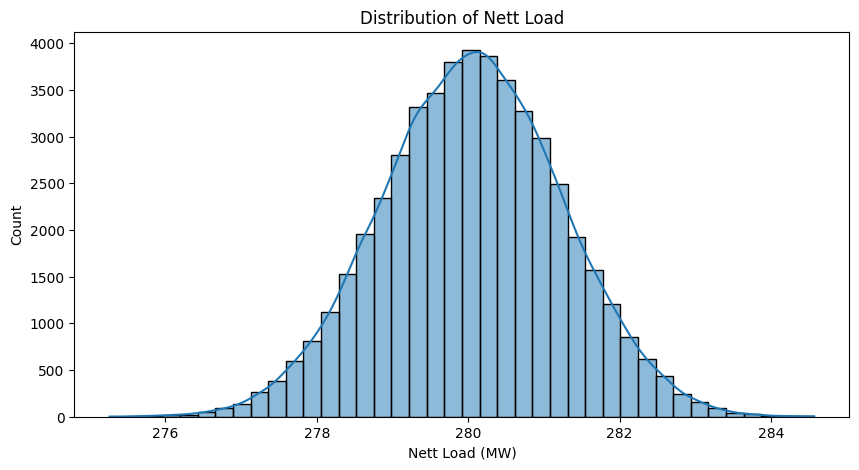

In [11]:
plt.figure(figsize=(10,5))

sns.histplot(
    df[TARGET],
    bins=40,
    kde=True
)

plt.title("Distribution of Nett Load")
plt.show()

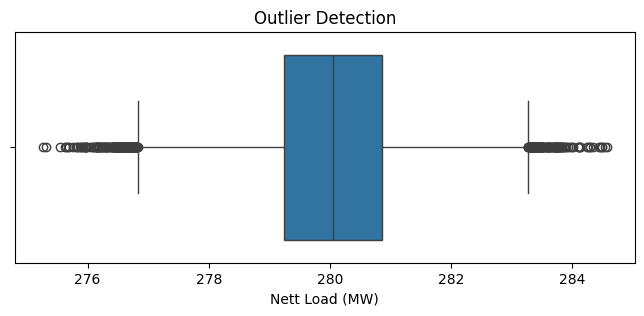

In [12]:
plt.figure(figsize=(8,3))

sns.boxplot(
    x=df[TARGET]
)

plt.title("Outlier Detection")
plt.show()

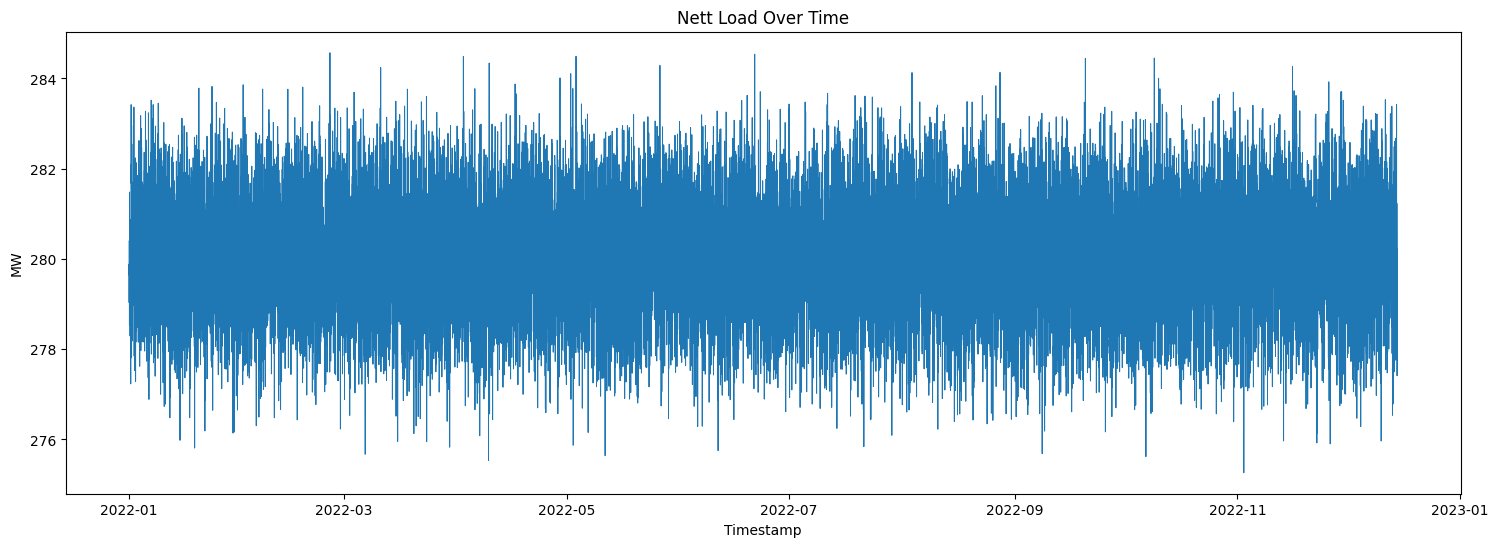

In [13]:
plt.figure(figsize=(18,6))

plt.plot(
    df["Timestamp"],
    df[TARGET],
    linewidth=0.7
)

plt.title("Nett Load Over Time")

plt.xlabel("Timestamp")

plt.ylabel("MW")

plt.show()

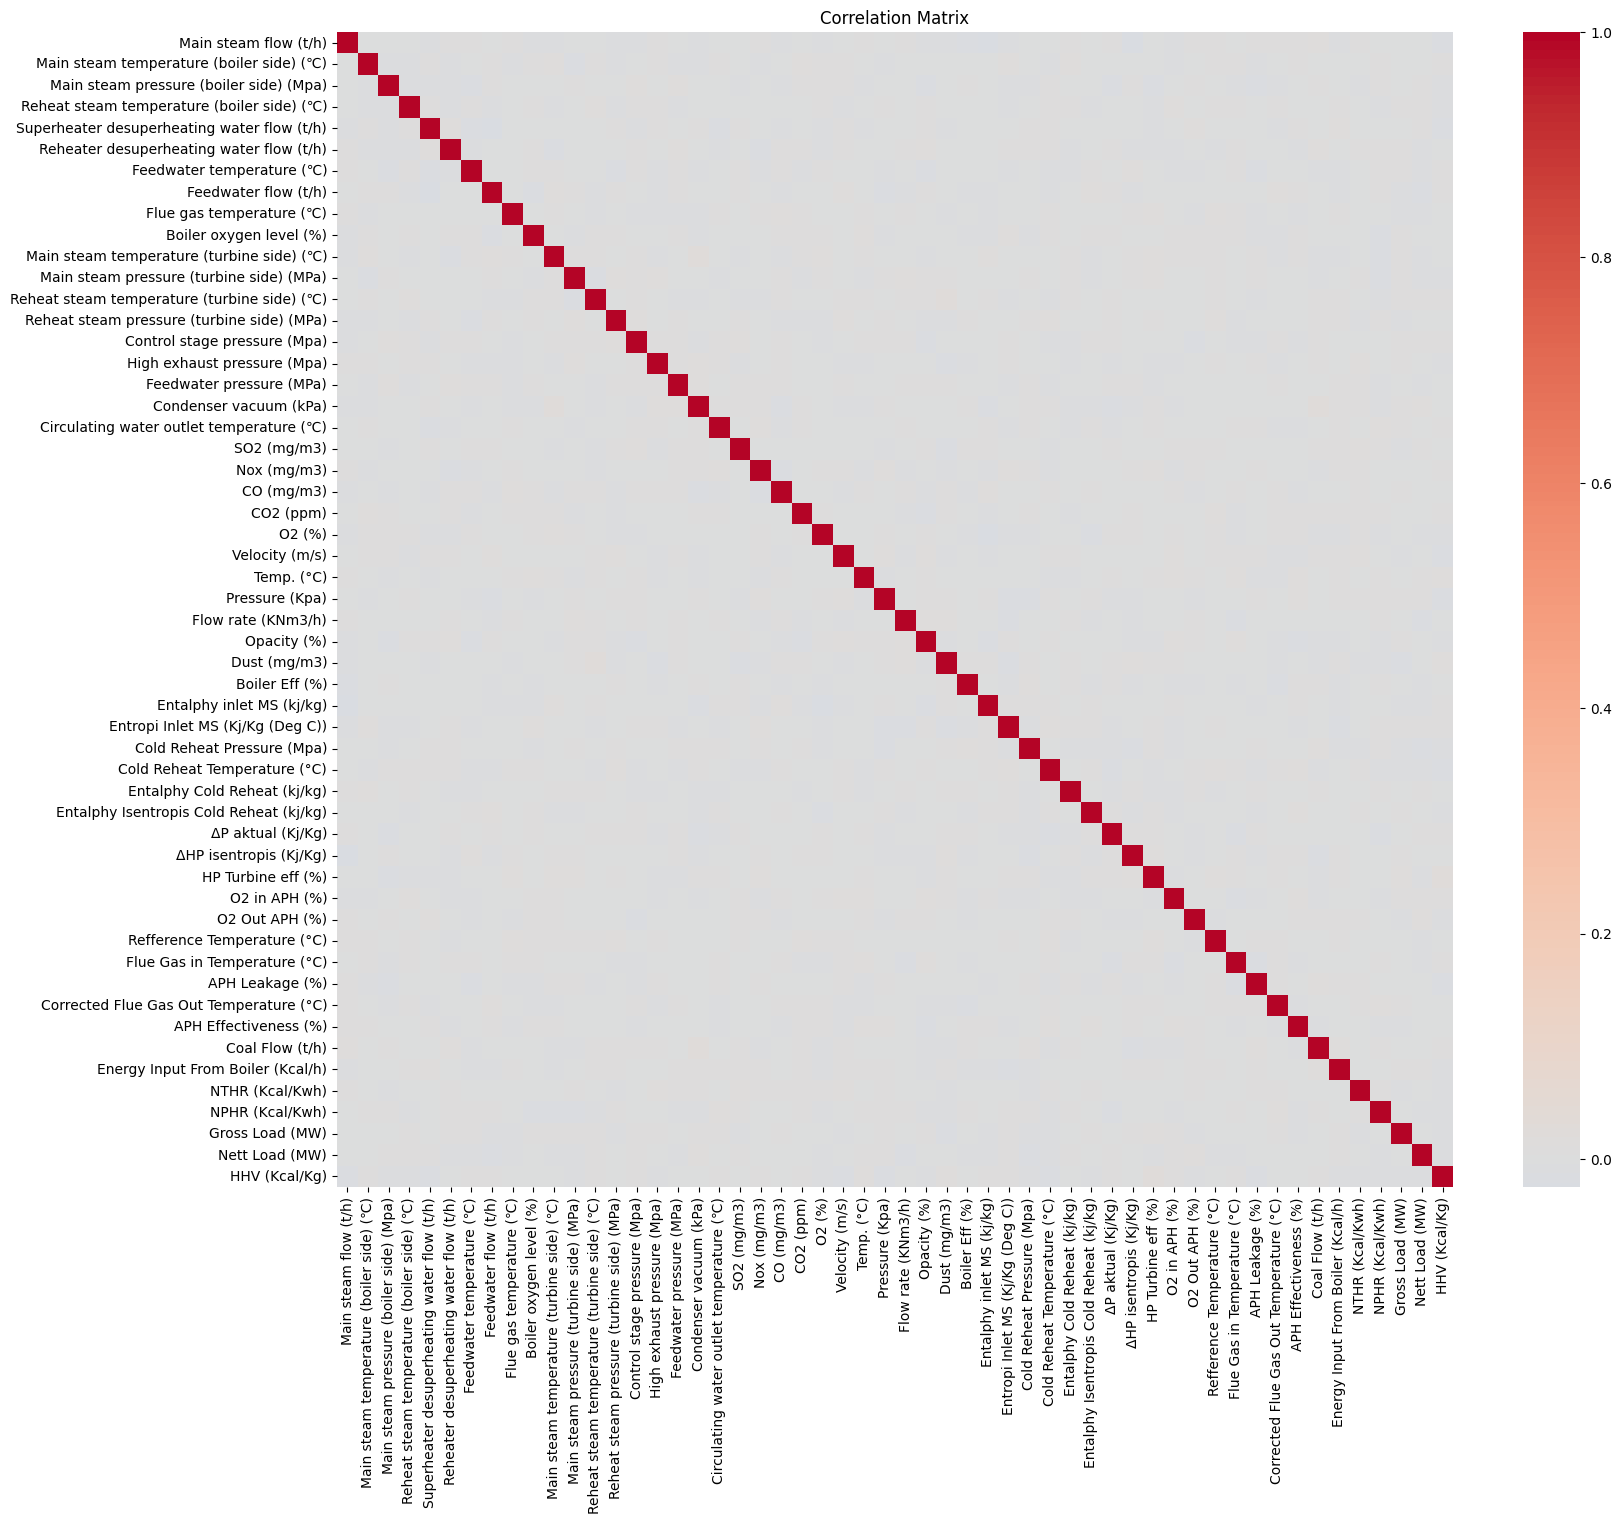

In [14]:
corr = df.drop(columns=["Timestamp"]).corr()

plt.figure(figsize=(18,15))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.show()

In [15]:
corr_target = (
    corr[TARGET]
    .sort_values(ascending=False)
)

display(corr_target.head(20))

Nett Load (MW)                                 1.000000
O2 Out APH (%)                                 0.011652
Condenser vacuum (kPa)                         0.011619
Pressure (Kpa)                                 0.011125
O2 in APH (%)                                  0.010313
Reheat steam temperature (boiler side) (℃)     0.009346
Energy Input From Boiler (Kcal/h)              0.006450
Temp. (°C)                                     0.006092
Superheater desuperheating water flow (t/h)    0.005866
ΔP aktual (Kj/Kg)                              0.005597
Control stage pressure (Mpa)                   0.005510
Reheat steam temperature (turbine side) (℃)    0.004745
SO2 (mg/m3)                                    0.004677
Entalphy Cold Reheat (kj/kg)                   0.004435
Entropi Inlet MS (Kj/Kg (Deg C))               0.004415
Main steam pressure (boiler side) (Mpa)        0.003209
Coal Flow (t/h)                                0.002342
Dust (mg/m3)                                   0

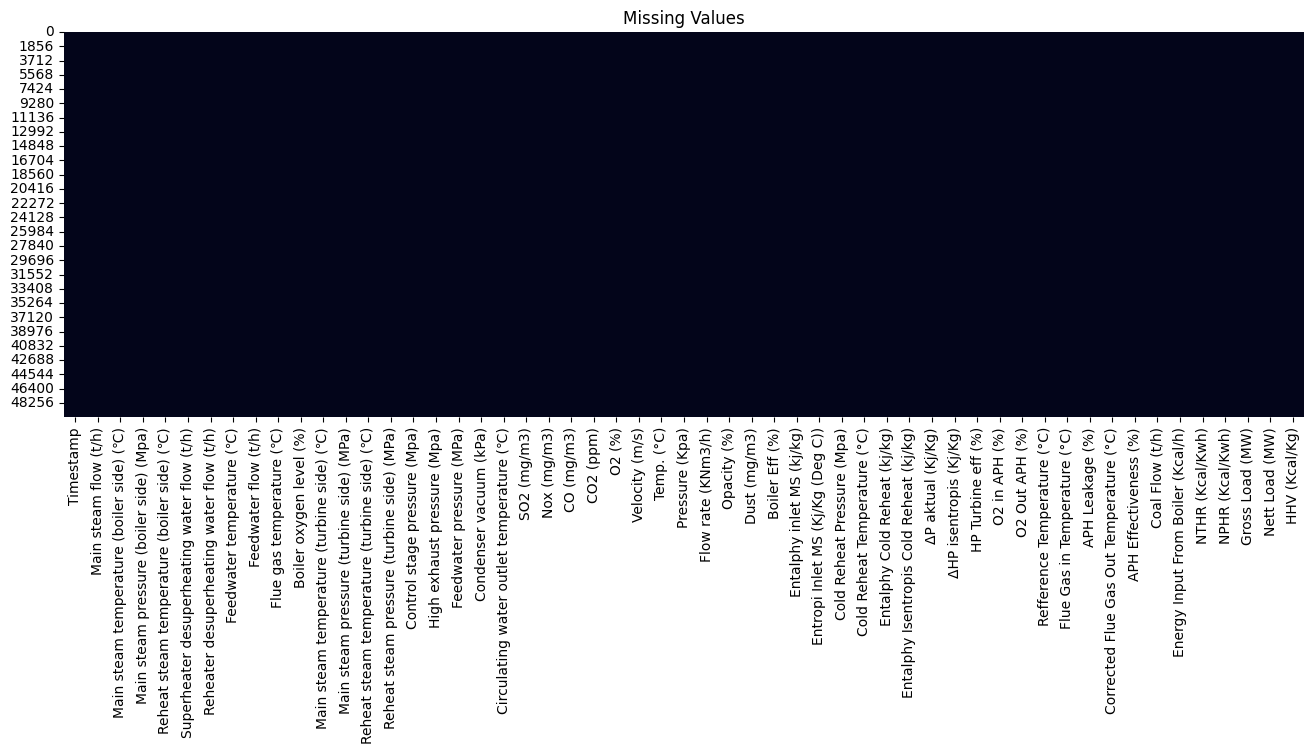

In [16]:
plt.figure(figsize=(16,5))

sns.heatmap(
    df.isnull(),
    cbar=False
)

plt.title("Missing Values")

plt.show()

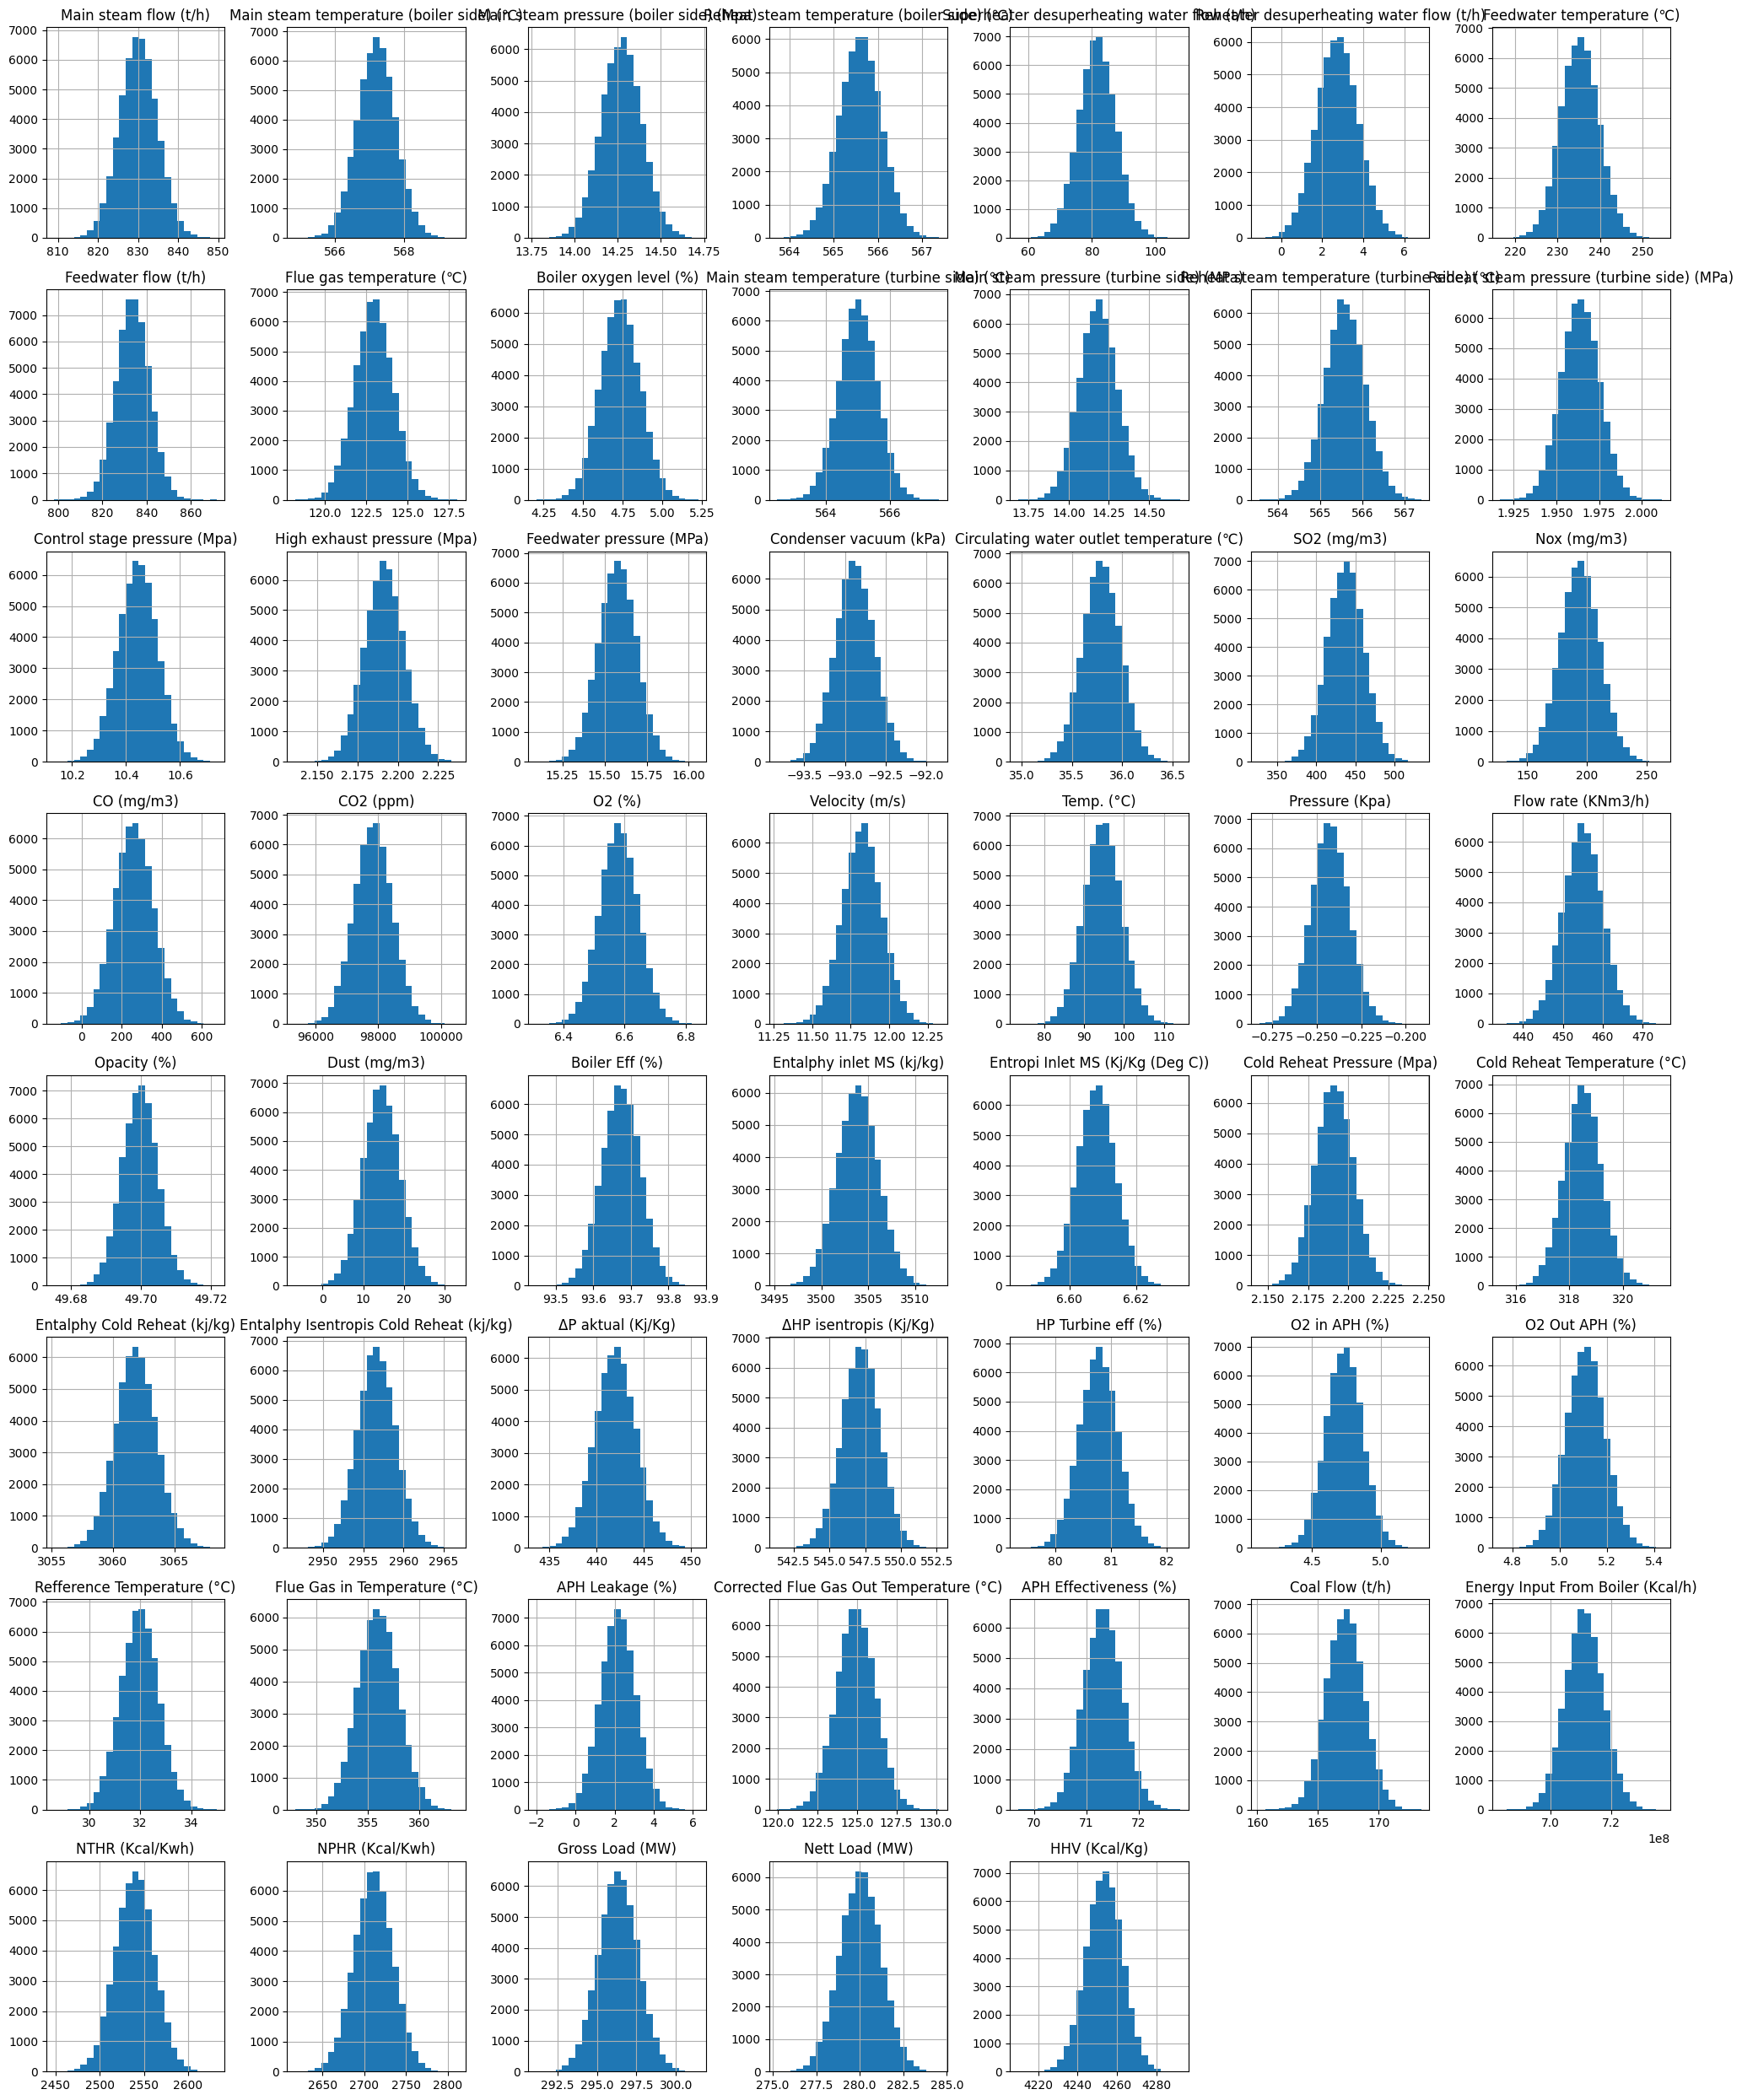

In [17]:
numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols].hist(
    figsize=(20,25),
    bins=25
)

plt.tight_layout()

plt.show()

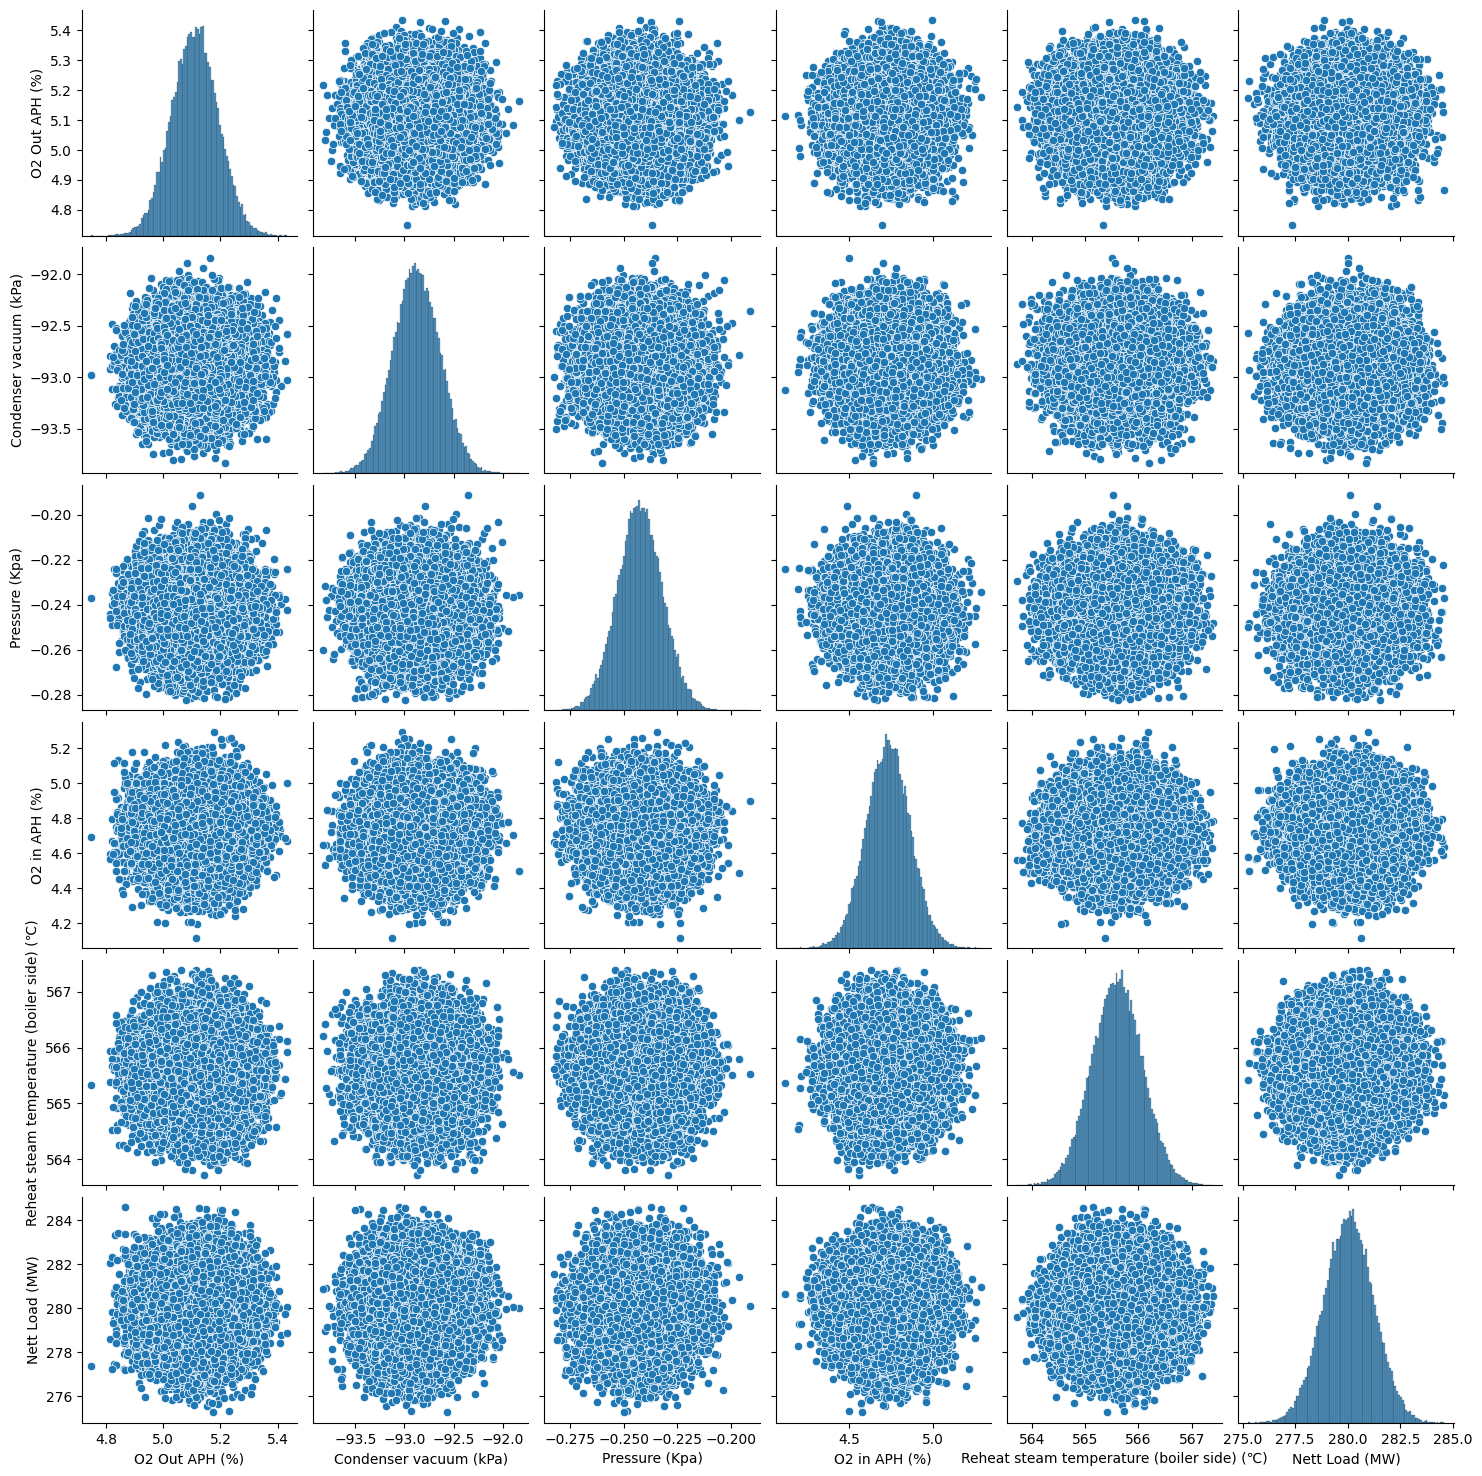

In [18]:
top_features = corr_target.index[1:6]

sns.pairplot(
    df[
        list(top_features)+[TARGET]
    ]
)

plt.show()

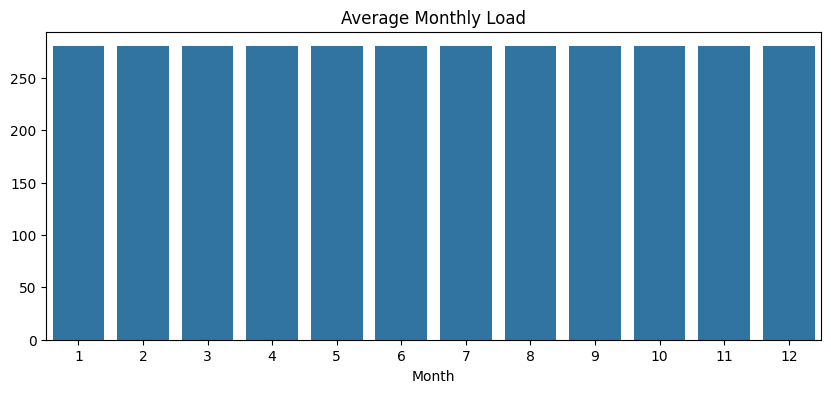

In [19]:
df["Month"] = df["Timestamp"].dt.month

monthly = (
    df.groupby("Month")[TARGET]
      .mean()
)

plt.figure(figsize=(10,4))

sns.barplot(
    x=monthly.index,
    y=monthly.values
)

plt.title("Average Monthly Load")

plt.show()

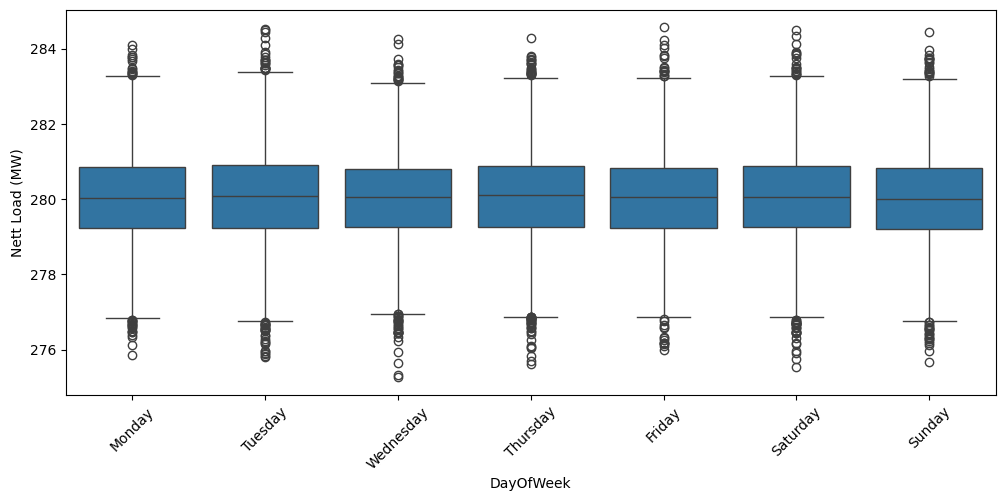

In [20]:
df["DayOfWeek"] = df["Timestamp"].dt.day_name()

order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

plt.figure(figsize=(12,5))

sns.boxplot(
    x="DayOfWeek",
    y=TARGET,
    data=df,
    order=order
)

plt.xticks(rotation=45)

plt.show()

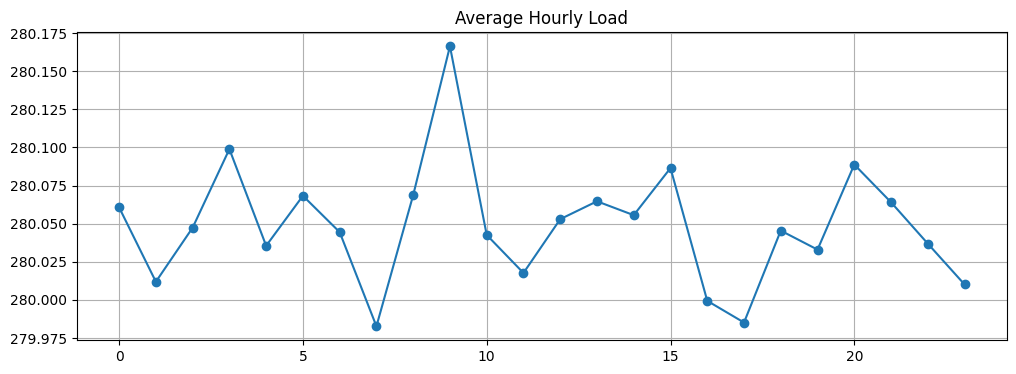

In [21]:
df["Hour"] = df["Timestamp"].dt.hour

hourly = (
    df.groupby("Hour")[TARGET]
      .mean()
)

plt.figure(figsize=(12,4))

plt.plot(
    hourly.index,
    hourly.values,
    marker="o"
)

plt.grid()

plt.title("Average Hourly Load")

plt.show()

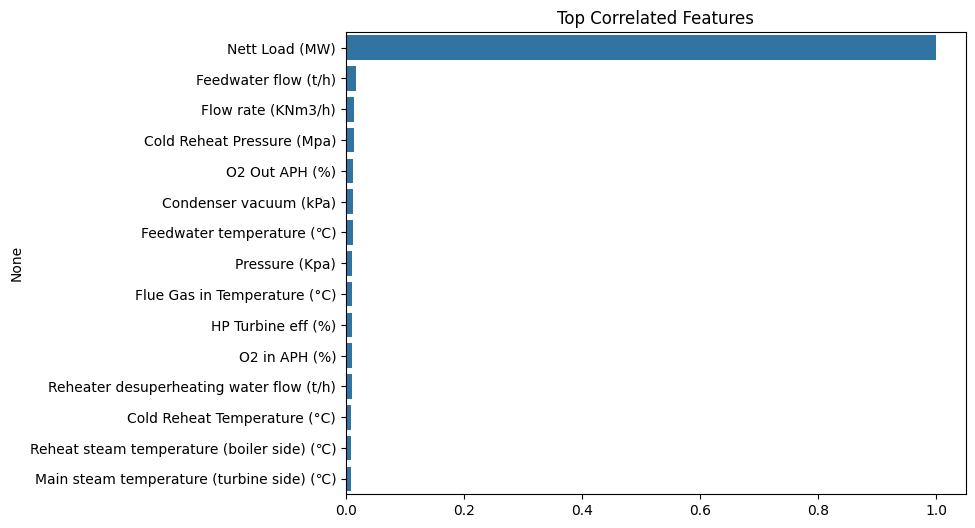

In [22]:
top15 = (
    corr_target
    .abs()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(8,6))

sns.barplot(
    x=top15.values,
    y=top15.index
)

plt.title("Top Correlated Features")

plt.show()

# 🛠 Phase 3 – Advanced Feature Engineering

Feature engineering is one of the most important stages of any machine learning project.

In this section we:

- Create rich datetime features
- Generate cyclic time features
- Create lag features
- Create rolling statistics
- Remove data leakage
- Prepare the final feature matrix

In [23]:
# ==========================================================
# Create Working Copy
# ==========================================================

df_model = df.copy()

print("Working DataFrame Shape:", df_model.shape)

Working DataFrame Shape: (50091, 58)


In [24]:
# ==========================================================
# Datetime Features
# ==========================================================

df_model["Year"] = df_model["Timestamp"].dt.year
df_model["Month"] = df_model["Timestamp"].dt.month
df_model["Quarter"] = df_model["Timestamp"].dt.quarter

df_model["Day"] = df_model["Timestamp"].dt.day
df_model["DayOfWeek"] = df_model["Timestamp"].dt.dayofweek
df_model["DayOfYear"] = df_model["Timestamp"].dt.dayofyear

df_model["WeekOfYear"] = (
    df_model["Timestamp"]
    .dt.isocalendar()
    .week
    .astype(int)
)

df_model["Hour"] = df_model["Timestamp"].dt.hour

df_model["Minute"] = df_model["Timestamp"].dt.minute

df_model["Weekend"] = (
    df_model["DayOfWeek"] >= 5
).astype(int)

print("Datetime features created.")

Datetime features created.


In [25]:
# ==========================================================
# Cyclic Encoding
# ==========================================================

df_model["Hour_sin"] = np.sin(
    2*np.pi*df_model["Hour"]/24
)

df_model["Hour_cos"] = np.cos(
    2*np.pi*df_model["Hour"]/24
)

df_model["Month_sin"] = np.sin(
    2*np.pi*df_model["Month"]/12
)

df_model["Month_cos"] = np.cos(
    2*np.pi*df_model["Month"]/12
)

df_model["DayOfWeek_sin"] = np.sin(
    2*np.pi*df_model["DayOfWeek"]/7
)

df_model["DayOfWeek_cos"] = np.cos(
    2*np.pi*df_model["DayOfWeek"]/7
)

print("Cyclic features added.")

Cyclic features added.


In [26]:
# ==========================================================
# Lag Features
# ==========================================================

TARGET = "Nett Load (MW)"

lags = [1, 2, 3, 6, 12]

for lag in lags:
    df_model[f"{TARGET}_lag_{lag}"] = (
        df_model[TARGET]
        .shift(lag)
    )

print("Lag features created.")

Lag features created.


In [27]:
# ==========================================================
# Rolling Statistics
# ==========================================================

windows = [3, 6, 12]

for window in windows:

    shifted = df_model[TARGET].shift(1)

    df_model[f"rolling_mean_{window}"] = (
        shifted
        .rolling(window)
        .mean()
    )

    df_model[f"rolling_std_{window}"] = (
        shifted
        .rolling(window)
        .std()
    )

    df_model[f"rolling_min_{window}"] = (
        shifted
        .rolling(window)
        .min()
    )

    df_model[f"rolling_max_{window}"] = (
        shifted
        .rolling(window)
        .max()
    )

print("Rolling features created.")

Rolling features created.


In [28]:
# ==========================================================
# Remove Leakage Columns
# ==========================================================

TARGET = "Nett Load (MW)"

leakage_columns = [

    "Timestamp",

    "Gross Load (MW)",

]

for col in leakage_columns:
    if col in df_model.columns:
        print("Removing:", col)

df_model = df_model.drop(
    columns=leakage_columns,
    errors="ignore"
)

print(df_model.shape)

Removing: Timestamp
Removing: Gross Load (MW)
(50091, 86)


In [29]:
# ==========================================================
# Remove Initial NaNs
# ==========================================================

print("Before:", df_model.shape)

df_model = df_model.dropna()

print("After :", df_model.shape)

Before: (50091, 86)
After : (50079, 86)


In [30]:
# ==========================================================
# Prepare X and y
# ==========================================================

X = df_model.drop(columns=[TARGET])

y = df_model[TARGET]

print("Features :", X.shape)
print("Target   :", y.shape)

Features : (50079, 85)
Target   : (50079,)


In [31]:
feature_summary = pd.DataFrame({

    "Feature": X.columns,

    "Datatype": X.dtypes.values

})

display(feature_summary)

,Feature,Datatype
0,Main steam flow (t/h),float64
1,Main steam temperature (boiler side) (℃),float64
2,Main steam pressure (boiler side) (Mpa),float64
3,Reheat steam temperature (boiler side) (℃),float64
4,Superheater desuperheating water flow (t/h),float64
5,Reheater desuperheating water flow (t/h),float64
6,Feedwater temperature (℃),float64
7,Feedwater flow (t/h),float64
8,Flue gas temperature (℃),float64
9,Boiler oxygen level (%),float64


In [32]:
print("Memory Usage")

print(
    X.memory_usage(deep=True).sum()/1024**2,
    "MB"
)

Memory Usage
31.329940795898438 MB


# 🤖 Phase 4 – Machine Learning Model Training

In this phase we:

- Create a chronological train/test split
- Train multiple ensemble models
- Evaluate each model using multiple metrics
- Compare model performance
- Select the best model

In [33]:
# ==========================================================
# Chronological Train/Test Split
# ==========================================================

split_index = int(len(df_model) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("="*60)
print("Training Samples :", len(X_train))
print("Testing Samples  :", len(X_test))
print("="*60)

Training Samples : 40063
Testing Samples  : 10016


In [34]:
# ==========================================================
# Evaluation Function
# ==========================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

def evaluate_model(model, X_test, y_test):

    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)

    rmse = np.sqrt(mean_squared_error(y_test, pred))

    r2 = r2_score(y_test, pred)

    mape = np.mean(
        np.abs((y_test - pred)/y_test)
    )*100

    return {

        "MAE": mae,

        "RMSE": rmse,

        "MAPE": mape,

        "R2": r2,

        "Prediction": pred

    }

In [35]:
# ==========================================================
# Models
# ==========================================================

models = {

    "Random Forest":
        RandomForestRegressor(

            n_estimators=300,

            random_state=42,

            n_jobs=-1
        ),

    "Extra Trees":
        ExtraTreesRegressor(

            n_estimators=300,

            random_state=42,

            n_jobs=-1
        ),

    "XGBoost":
        XGBRegressor(

            n_estimators=500,

            learning_rate=0.05,

            max_depth=8,

            subsample=0.8,

            colsample_bytree=0.8,

            random_state=42
        ),

    "LightGBM":
        LGBMRegressor(

            n_estimators=500,

            learning_rate=0.05,

            random_state=42
        ),

    "CatBoost":
        CatBoostRegressor(

            iterations=500,

            learning_rate=0.05,

            verbose=False,

            random_seed=42
        )

}

In [36]:
# ==========================================================
# Train Models
# ==========================================================

results = []

trained_models = {}

for name, model in models.items():

    print("="*60)

    print("Training :", name)

    model.fit(

        X_train,

        y_train

    )

    metrics = evaluate_model(

        model,

        X_test,

        y_test

    )

    trained_models[name] = model

    results.append({

        "Model": name,

        "MAE": metrics["MAE"],

        "RMSE": metrics["RMSE"],

        "MAPE": metrics["MAPE"],

        "R2": metrics["R2"]

    })

print("Training Completed.")

Training : Random Forest
Training : Extra Trees
Training : XGBoost
Training : LightGBM
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.028156 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 18051
[LightGBM] [Info] Number of data points in the train set: 40063, number of used features: 84
[LightGBM] [Info] Start training from score 280.045257
Training : CatBoost
Training Completed.


In [37]:
results_df = (

    pd.DataFrame(results)

    .sort_values(

        by="RMSE"

    )

)

display(results_df)

,Model,MAE,RMSE,MAPE,R2
4,CatBoost,0.420612,0.527375,0.150186,0.805549
3,LightGBM,0.421367,0.528470,0.150455,0.804740
2,XGBoost,0.428670,0.537114,0.153053,0.798301
1,Extra Trees,0.437418,0.549487,0.156183,0.788901
0,Random Forest,0.438452,0.551108,0.156555,0.787654


In [38]:
best_model_name = results_df.iloc[0]["Model"]

best_model = trained_models[best_model_name]

print("="*60)

print("Best Model")

print(best_model_name)

print("="*60)

Best Model
CatBoost


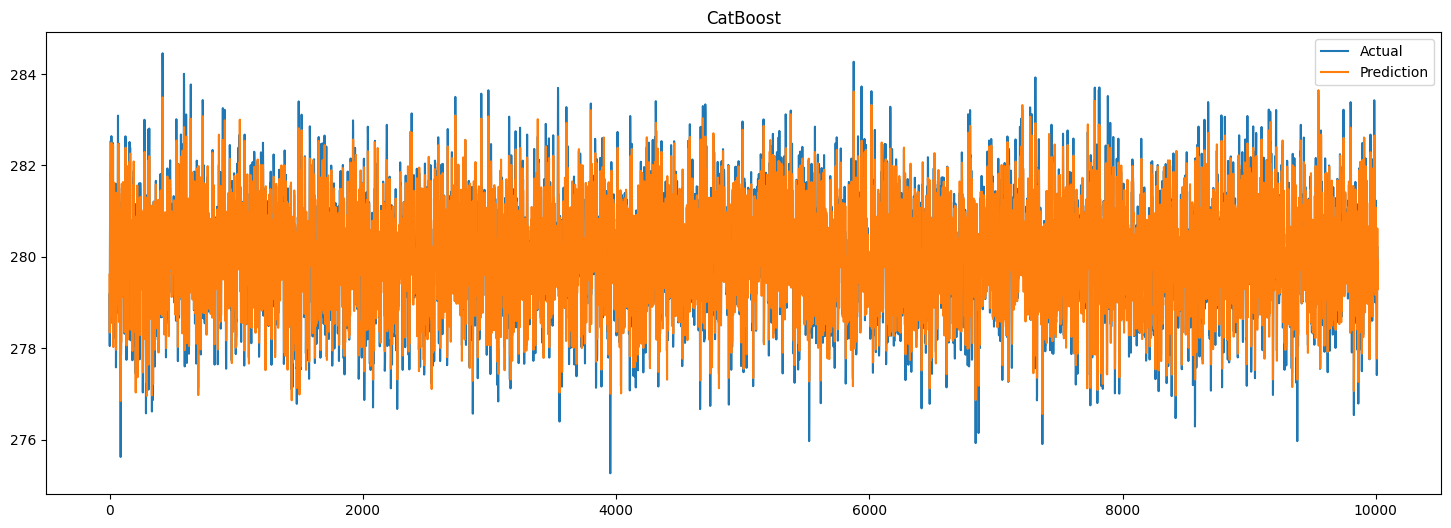

In [39]:
prediction = best_model.predict(X_test)

plt.figure(figsize=(18,6))

plt.plot(

    y_test.values,

    label="Actual"

)

plt.plot(

    prediction,

    label="Prediction"

)

plt.legend()

plt.title(best_model_name)

plt.show()

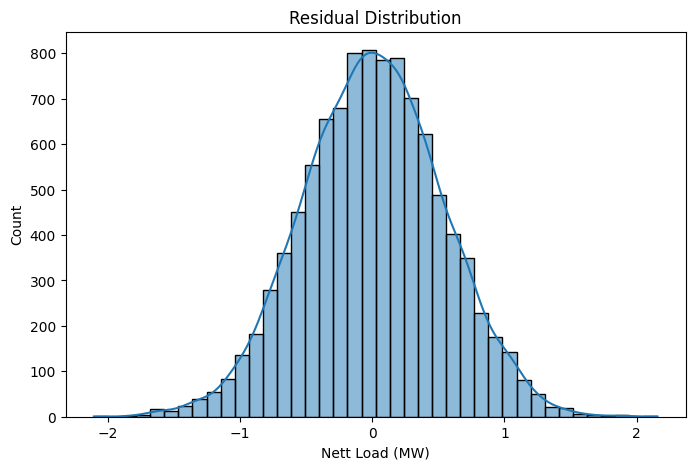

In [40]:
residual = y_test - prediction

plt.figure(figsize=(8,5))

sns.histplot(

    residual,

    bins=40,

    kde=True

)

plt.title("Residual Distribution")

plt.show()

In [41]:
results_df.to_csv(

    "/kaggle/working/model_comparison.csv",

    index=False

)

print("Leaderboard saved.")

Leaderboard saved.


# 🎯 Phase 5 – Hyperparameter Optimization & Model Persistence

This phase improves the performance of the best-performing model using Bayesian Optimization (Optuna).

Objectives:

- Automatic hyperparameter search
- Improved prediction accuracy
- Feature importance analysis
- Save trained model
- Save feature list
- Save evaluation metrics

In [42]:
print("="*70)
print("Best Model from Phase 4")
print("="*70)

print(best_model_name)

Best Model from Phase 4
CatBoost


In [43]:
import optuna
import json

from sklearn.model_selection import TimeSeriesSplit

In [50]:
tscv = TimeSeriesSplit(
    n_splits=3
)

In [51]:
def objective(trial):

    params = {

        "n_estimators": trial.suggest_int(
            "n_estimators",
            200,
            800
        ),

        "max_depth": trial.suggest_int(
            "max_depth",
            3,
            12
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.3,
            log=True
        ),

        "subsample": trial.suggest_float(
            "subsample",
            0.6,
            1.0
        ),

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree",
            0.6,
            1.0
        ),

        "random_state":42,

        "n_jobs":-1

    }

    rmse_scores=[]

    for train_idx,val_idx in tscv.split(X_train):

        X_tr = X_train.iloc[train_idx]
        X_val = X_train.iloc[val_idx]

        y_tr = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]

        model = XGBRegressor(**params)

        model.fit(X_tr,y_tr)

        pred = model.predict(X_val)

        rmse = np.sqrt(
            mean_squared_error(
                y_val,
                pred
            )
        )

        rmse_scores.append(rmse)

    return np.mean(rmse_scores)

In [53]:
study = optuna.create_study(
    direction="minimize"
)

study.optimize(
    objective,
    n_trials=10,
    show_progress_bar=True
)

[I 2026-07-05 02:36:18,506] A new study created in memory with name: no-name-65866efb-8db2-4062-807f-07ddc74b6646


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2026-07-05 02:36:41,220] Trial 0 finished with value: 0.5557909613455957 and parameters: {'n_estimators': 232, 'max_depth': 7, 'learning_rate': 0.014973865567781734, 'subsample': 0.9188849945456712, 'colsample_bytree': 0.745302111640471}. Best is trial 0 with value: 0.5557909613455957.
[I 2026-07-05 02:36:45,403] Trial 1 finished with value: 0.6007431539177394 and parameters: {'n_estimators': 261, 'max_depth': 3, 'learning_rate': 0.019131227525222276, 'subsample': 0.8879557933409339, 'colsample_bytree': 0.845164849987468}. Best is trial 0 with value: 0.5557909613455957.
[I 2026-07-05 02:37:25,389] Trial 2 finished with value: 0.5671251244147725 and parameters: {'n_estimators': 769, 'max_depth': 6, 'learning_rate': 0.18635748894389065, 'subsample': 0.9813919820069088, 'colsample_bytree': 0.8471892354776236}. Best is trial 0 with value: 0.5557909613455957.
[I 2026-07-05 02:37:37,461] Trial 3 finished with value: 0.5490195957835088 and parameters: {'n_estimators': 605, 'max_depth': 4, 

In [54]:
print("="*70)

print("Best Parameters")

print("="*70)

study.best_params

Best Parameters


{'n_estimators': 402,
 'max_depth': 4,
 'learning_rate': 0.1817143027024783,
 'subsample': 0.9266610791300662,
 'colsample_bytree': 0.7592069221713958}

In [55]:
best_params = study.best_params

best_params["random_state"]=42
best_params["n_jobs"]=-1

optimized_model = XGBRegressor(
    **best_params
)

optimized_model.fit(
    X_train,
    y_train
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.7592069221713958, device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, feature_weights=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1817143027024783,
             max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=4, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=402, n_jobs=-1,
             num_parallel_tree=None, ...)

In [56]:
optimized_metrics = evaluate_model(

    optimized_model,

    X_test,

    y_test

)

print("="*70)

for k,v in optimized_metrics.items():

    if k!="Prediction":

        print(k,":",v)

MAE : 0.42263286730638727
RMSE : 0.529851327762721
MAPE : 0.15090157400234153
R2 : 0.8037183392577907


In [57]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":optimized_model.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

display(
    importance.head(20)
)

,Feature,Importance
68,Nett Load (MW)_lag_1,0.467373
76,rolling_max_3,0.086912
75,rolling_min_3,0.065730
69,Nett Load (MW)_lag_2,0.057922
73,rolling_mean_3,0.036590
74,rolling_std_3,0.015937
70,Nett Load (MW)_lag_3,0.014165
80,rolling_max_6,0.006016
77,rolling_mean_6,0.004562
78,rolling_std_6,0.004516


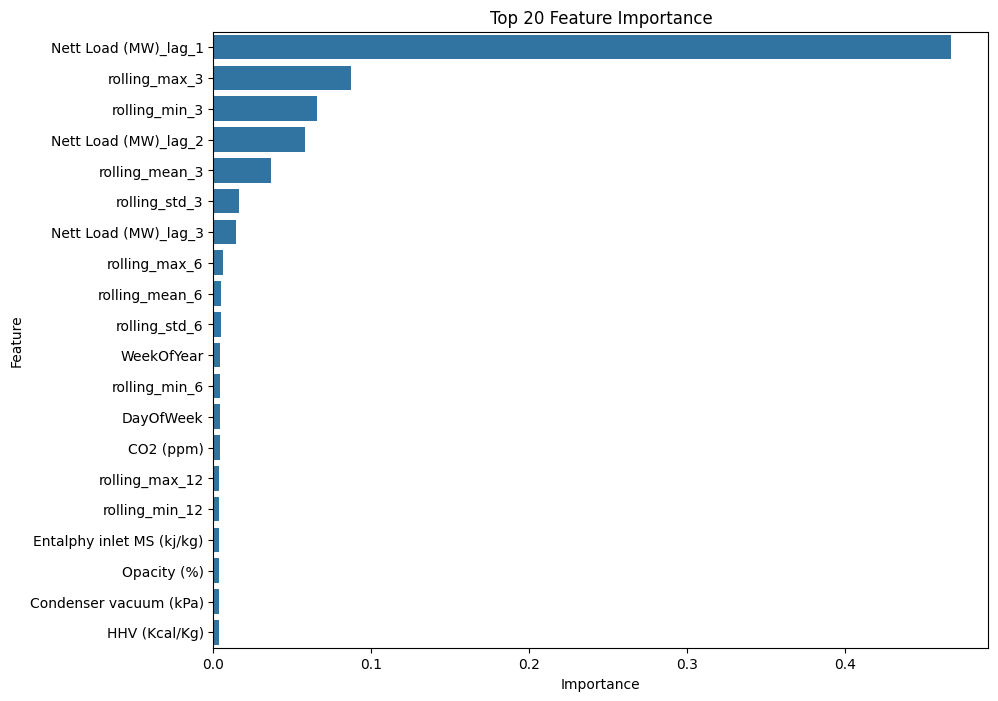

In [58]:
plt.figure(figsize=(10,8))

sns.barplot(

    data=importance.head(20),

    x="Importance",

    y="Feature"

)

plt.title("Top 20 Feature Importance")

plt.show()

In [59]:
joblib.dump(

    optimized_model,

    "/kaggle/working/best_model.pkl"

)

print("Model Saved")

Model Saved


In [60]:
joblib.dump(

    list(X.columns),

    "/kaggle/working/feature_columns.pkl"

)

print("Feature List Saved")

Feature List Saved


In [61]:
metrics = {

    "Model":"Optimized XGBoost",

    "MAE":optimized_metrics["MAE"],

    "RMSE":optimized_metrics["RMSE"],

    "MAPE":optimized_metrics["MAPE"],

    "R2":optimized_metrics["R2"]

}

with open(

    "/kaggle/working/metrics.json",

    "w"

) as f:

    json.dump(

        metrics,

        f,

        indent=4

    )

print(metrics)

{'Model': 'Optimized XGBoost', 'MAE': 0.42263286730638727, 'RMSE': np.float64(0.529851327762721), 'MAPE': np.float64(0.15090157400234153), 'R2': 0.8037183392577907}


In [62]:
import joblib
import json
import os

os.makedirs("/kaggle/working/models", exist_ok=True)

# Save model
joblib.dump(optimized_model, "/kaggle/working/models/best_model.pkl")

# Save feature list
joblib.dump(list(X.columns), "/kaggle/working/models/feature_columns.pkl")

# Save metrics
with open("/kaggle/working/models/metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

print("All files saved successfully.")

All files saved successfully.
